In [3]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install Seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\DELL\Downloads\Python_Diwali_Sales_Analysis\Python_Diwali_Sales_Analysis\Diwali Sales Data.csv", encoding='unicode_escape')
#to avoid encoding error, use'unicode_escape'

In [9]:
df.shape #to show numbers of rows and column

(11251, 15)

In [23]:
df.head() #shows only first five rows

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


# DATA CLEANING

In [9]:
df.info() #to get info about columns

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), str(8)
memory usage: 1.1 MB


In [7]:
#drop unwanted columns
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)  #axis =1 means whole verticle row and #inplace =True updates original df(don't make copy)

In [8]:
df.head() #to see if those columns have been removed or not

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [10]:
#check for Null Values

pd.isnull(df).sum() #gives the total number of null values in each column

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [11]:
df.shape

(11251, 13)

In [14]:
df.dropna(inplace=True) #drop null values (BUT IT DELETES THE WHOLE ROW WITH NON NULL VALUES ALSO)

In [13]:
df.shape

(11239, 13)

In [15]:
#Change data type where ever needed
df['Amount']=df['Amount'].astype('int')

In [17]:
df['Amount'].dtypes #check Datatype of specific column

dtype('int64')

In [18]:
#rename columns
df.rename(columns= {"Marital_Status":'Shaadi'})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Shaadi,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


In [20]:
#describe() method gives statistical summary of the data in data frame(i.e mean, std, count,etc)
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [21]:
#or for specific Column
df[['Age','Orders']].describe()

,Age,Orders
count,11239.000000,11239.000000
mean,35.410357,2.489634
std,12.753866,1.114967
min,12.000000,1.000000
25%,27.000000,2.000000
50%,33.000000,2.000000
75%,43.000000,3.000000
max,92.000000,4.000000


## EXploratory Data Analysis

# Gender

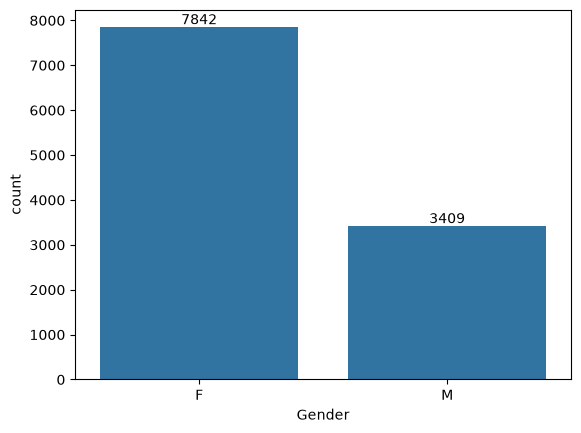

In [4]:
a= sns.countplot(x='Gender', data=df) #for getting a bar chart showing count of male and female
for bars in a.containers:
    a.bar_label(bars)     #for showing the count on the bars

#insight: Number of Female Buying dewali products is more than those of males

In [7]:
#Amount Spent by Male and female (total amount per gender)
sales_gen= df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
print(sales_gen)

  Gender       Amount
0      F  74335856.43
1      M  31913276.00


In [9]:
#or

sale=df.pivot_table(values='Amount', index='Gender', aggfunc='sum').sort_values(by='Amount',ascending=False)
print(sale)

             Amount
Gender             
F       74335856.43
M       31913276.00


Text(0.5, 1.0, 'Total Amount VS Gender')

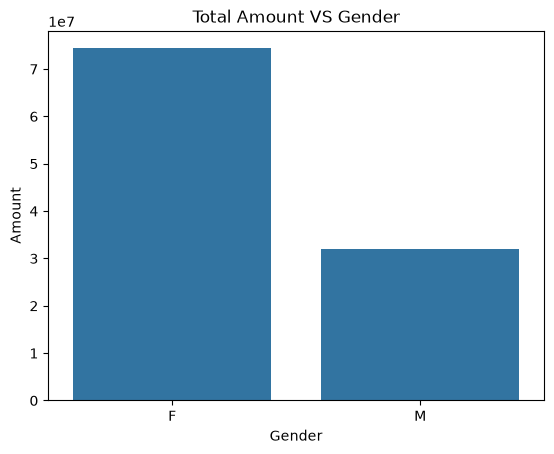

In [11]:
#visualising this total amount per gender
sns.barplot(x='Gender',y="Amount",data= sales_gen)
plt.title("Total Amount VS Gender")

#From above Graphs we can see that most of the buyers are Female and even the purchasing power of females are greater than men

# Age

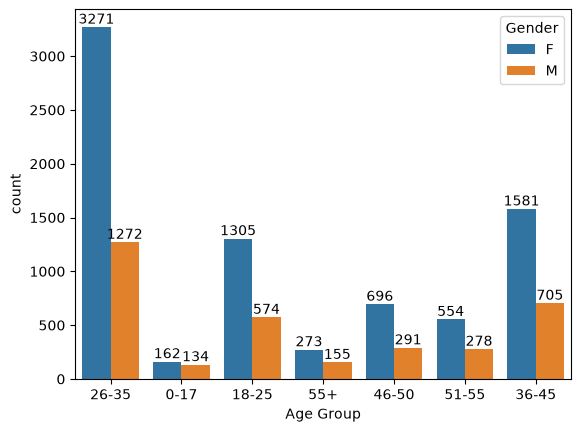

In [12]:
#Count number of people within that age_group
b=sns.countplot(x='Age Group', hue='Gender',data=df)

for bars in b.containers:
    b.bar_label(bars)

In [13]:
#total amount vs Age group
sales_age= df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
print(sales_age)

  Age Group       Amount
2     26-35  42613443.94
3     36-45  22144995.49
1     18-25  17240732.00
4     46-50   9207844.00
5     51-55   8261477.00
6       55+   4080987.00
0      0-17   2699653.00


<Axes: xlabel='Age Group', ylabel='Amount'>

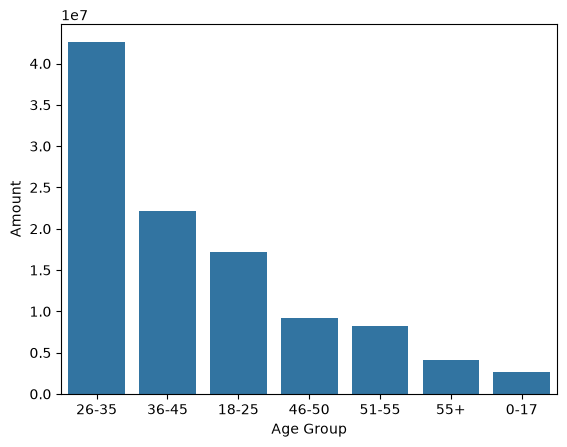

In [14]:
#visualising total amount vs age group
sns.barplot(x='Age Group',y='Amount', data=sales_age)

#from above graphs we can see that 26-35 Age Group(especially female) has high contribution in driving Diwali sales

# State

In [6]:
#Total Number of Orders From Top 10 States
sales_state= df.groupby(['State'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)
print(sales_state)

               State  Orders
14     Uttar Pradesh    4813
10       Maharashtra    3811
7          Karnataka    3241
2              Delhi    2744
9     Madhya Pradesh    2259
0     Andhra Pradesh    2054
5   Himachal Pradesh    1568
8             Kerala    1137
4            Haryana    1109
3            Gujarat    1070


<Axes: xlabel='State', ylabel='Orders'>

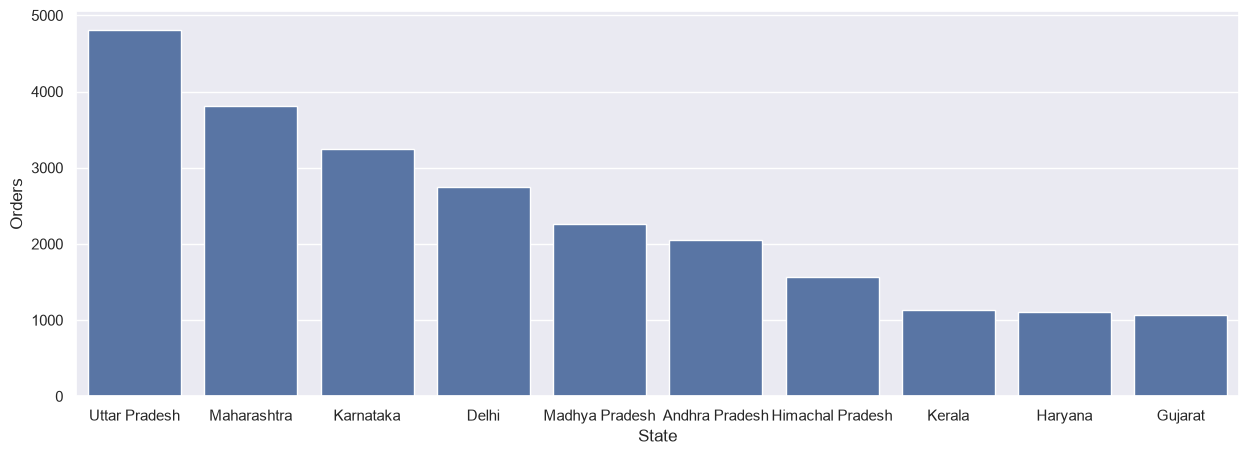

In [7]:
#visualising it

sns.set(rc={'figure.figsize':(15,5)}) #to maintain gaps between bars
sns.barplot(x='State', y='Orders', data=sales_state)

#we can see highest number of orders are from Uttarpradesh

In [10]:
#total Amount generated from Top 10 States
s=df.groupby(['State'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)
print(s)

               State       Amount
14     Uttar Pradesh  19374968.00
10       Maharashtra  14427543.00
7          Karnataka  13523540.00
2              Delhi  11603819.45
9     Madhya Pradesh   8101142.00
0     Andhra Pradesh   8037146.99
5   Himachal Pradesh   4963368.00
4            Haryana   4220175.00
1              Bihar   4022757.00
3            Gujarat   3946082.00


<Axes: xlabel='State', ylabel='Amount'>

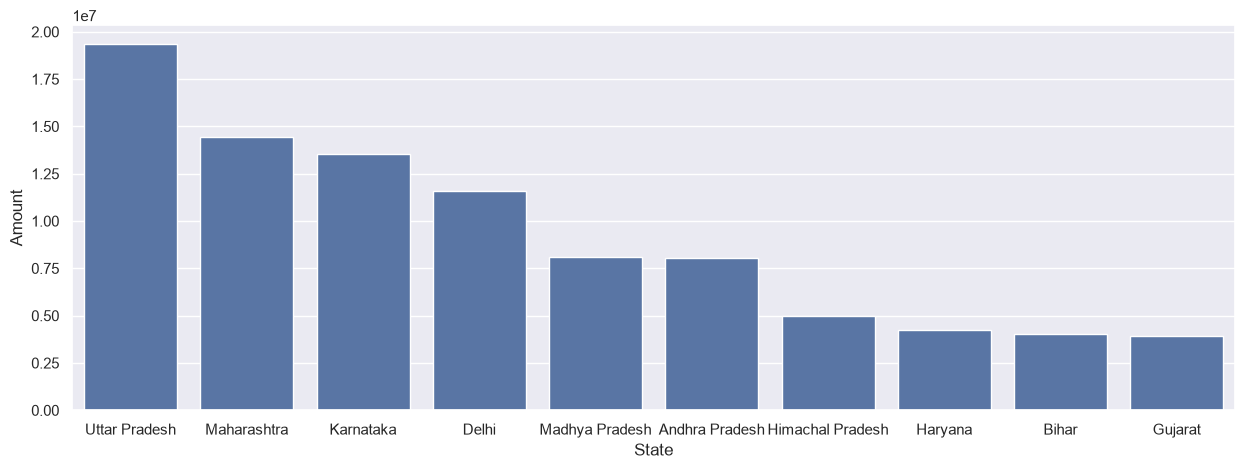

In [12]:
sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(x='State',y='Amount', data=s)

#we can see that highest revenue is generated by the state Uttar pradesh , Maharastra and Karnataka

# Marital Status

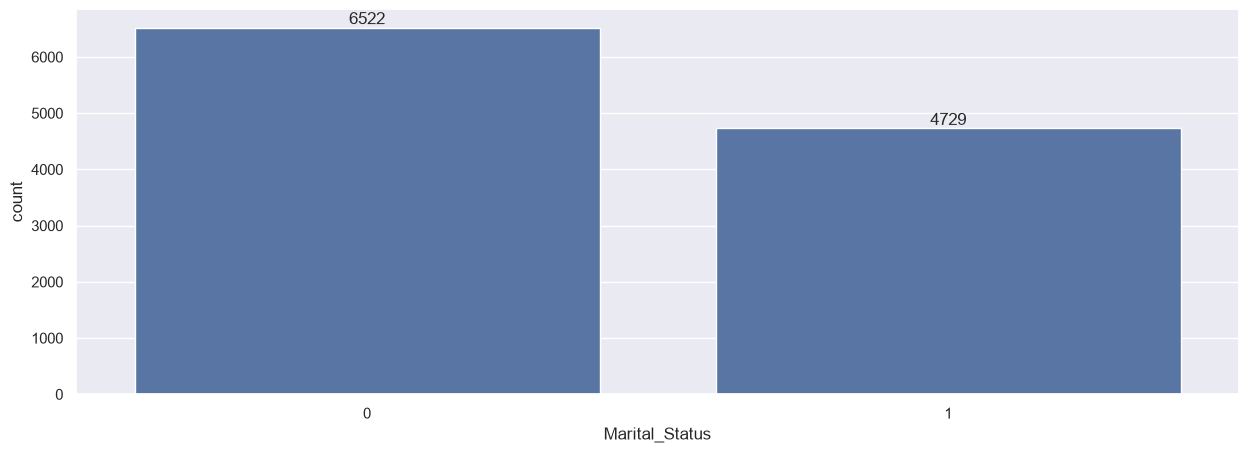

In [14]:
c=sns.countplot(x='Marital_Status', data=df)
for bars in c.containers:
    c.bar_label(bars)

#we can see mostly married(0) people are participating in buying products

In [30]:
# Total Amount per Marital status
d=df.groupby(['Marital_Status','Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
print(d)

   Marital_Status Gender       Amount
0               0      F  43786648.44
2               1      F  30549207.99
1               0      M  18338738.00
3               1      M  13574538.00


<Axes: xlabel='Marital_Status', ylabel='Amount'>

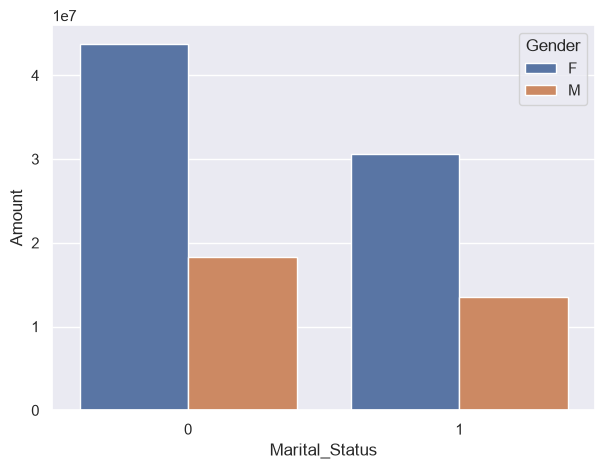

In [31]:
#visualising it
sns.set(rc={'figure.figsize':(7,5)})
sns.barplot(hue='Gender',x='Marital_Status',y='Amount',data=d)

#WE can see married people(especially female) contribute more to the Sales generation

# Occupation

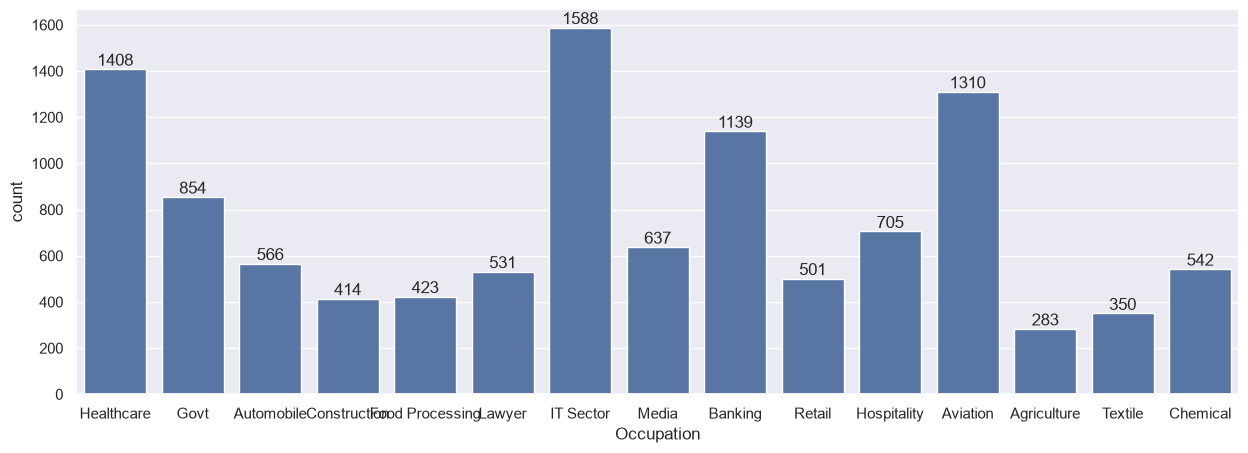

In [33]:
#count of occupation participating in purchase
sns.set(rc={'figure.figsize':(15,5)})
e=sns.countplot(x='Occupation',data=df)

for bars in e.containers:
    e.bar_label(bars)

#we can see that most of the buyers are From It, Healthcare and Aviation sector

In [34]:
#total amount per Occupation
sales_occ=df.groupby(['Occupation'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
print(sales_occ)

         Occupation       Amount
10        IT Sector  14755079.00
8        Healthcare  13034587.49
2          Aviation  12602298.00
3           Banking  10770610.95
7              Govt   8517212.00
9       Hospitality   6376405.00
12            Media   6295832.99
1        Automobile   5368596.00
4          Chemical   5297436.00
11           Lawyer   4981665.00
13           Retail   4783170.00
6   Food Processing   4070670.00
5      Construction   3597511.00
14          Textile   3204972.00
0       Agriculture   2593087.00


<Axes: xlabel='Occupation', ylabel='Amount'>

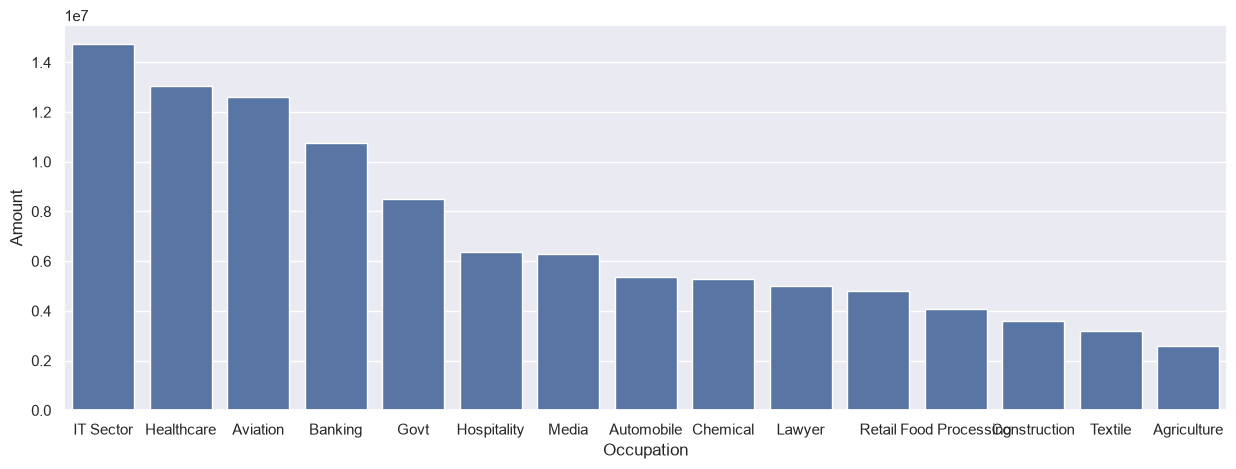

In [35]:
#visualising it
sns.barplot(x='Occupation',y='Amount',data=sales_occ)

#from these graphs we can see that IT, Healthcare and Aviation are the top three buyers and have high purchasing power also

# product Category

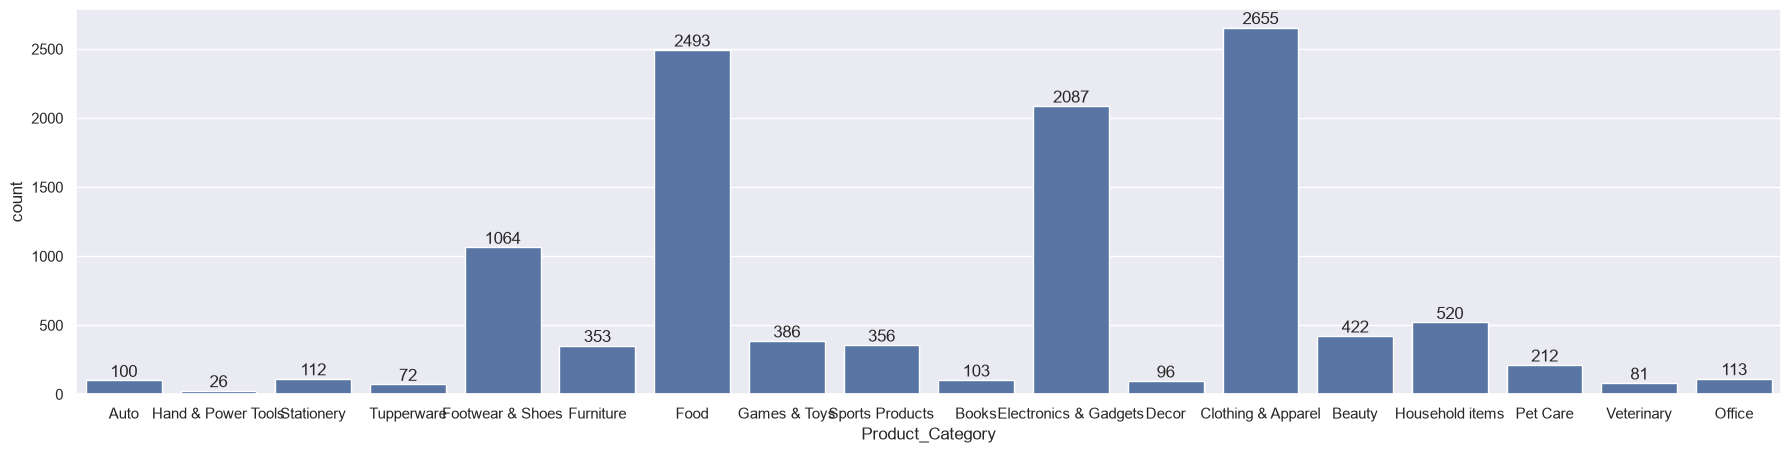

In [4]:
#Count of each Product involved
sns.set(rc={'figure.figsize':(22,5)})
f=sns.countplot(x='Product_Category', data=df)
for bars in f.containers:
    f.bar_label(bars)

#we can see that the highest number of Product Sold: Clothing, Food And Electronics

In [7]:
#Total Amount vs Product
sales_product=df.groupby(['Product_Category'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
print(sales_product)

         Product_Category       Amount
6                    Food  33933883.50
3      Clothing & Apparel  16495019.00
5   Electronics & Gadgets  15643846.00
7        Footwear & Shoes  15575209.45
8               Furniture   5440051.99
9            Games & Toys   4331694.00
14        Sports Products   3635933.00
1                  Beauty   1959484.00
0                    Auto   1958609.99
15             Stationery   1676051.50
11        Household items   1569337.00
16             Tupperware   1155642.00
2                   Books   1061478.00
4                   Decor    730360.00
13               Pet Care    482277.00
10     Hand & Power Tools    405618.00
17             Veterinary    112702.00
12                 Office     81936.00


<Axes: xlabel='Product_Category', ylabel='Amount'>

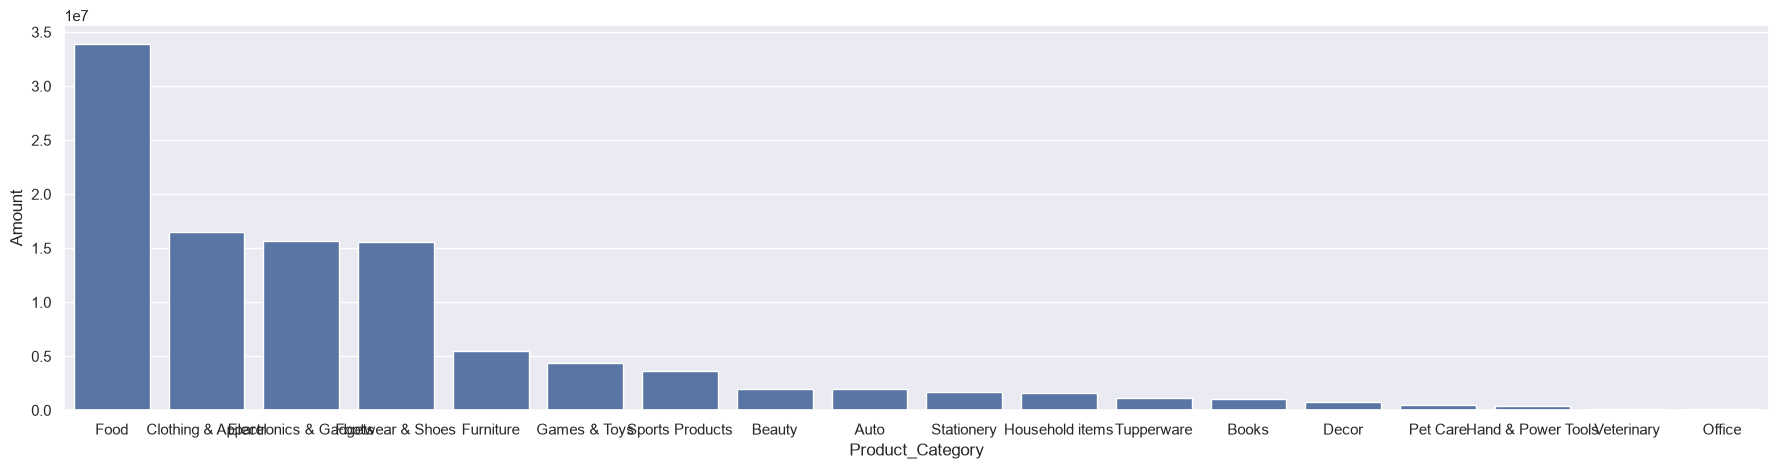

In [10]:
#visualise it
sns.barplot(x='Product_Category',y='Amount',data=sales_product)

#comparing above graphs we can see clothing is highest number of product sold where as Food is the product contributing to the Revenue 
#hence the top performing categories are Food(highest), Clothing and electronics

In [17]:
#product Id vs orders
sales_productID=df.groupby(['Product_ID'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)
print(sales_productID)

     Product_ID  Orders
1680  P00265242     127
645   P00110942     116
1505  P00237542      91
1147  P00184942      82
680   P00114942      79
172   P00025442      79
709   P00117942      76
889   P00145042      76
299   P00044442      75
644   P00110842      74


<Axes: xlabel='Product_ID', ylabel='Orders'>

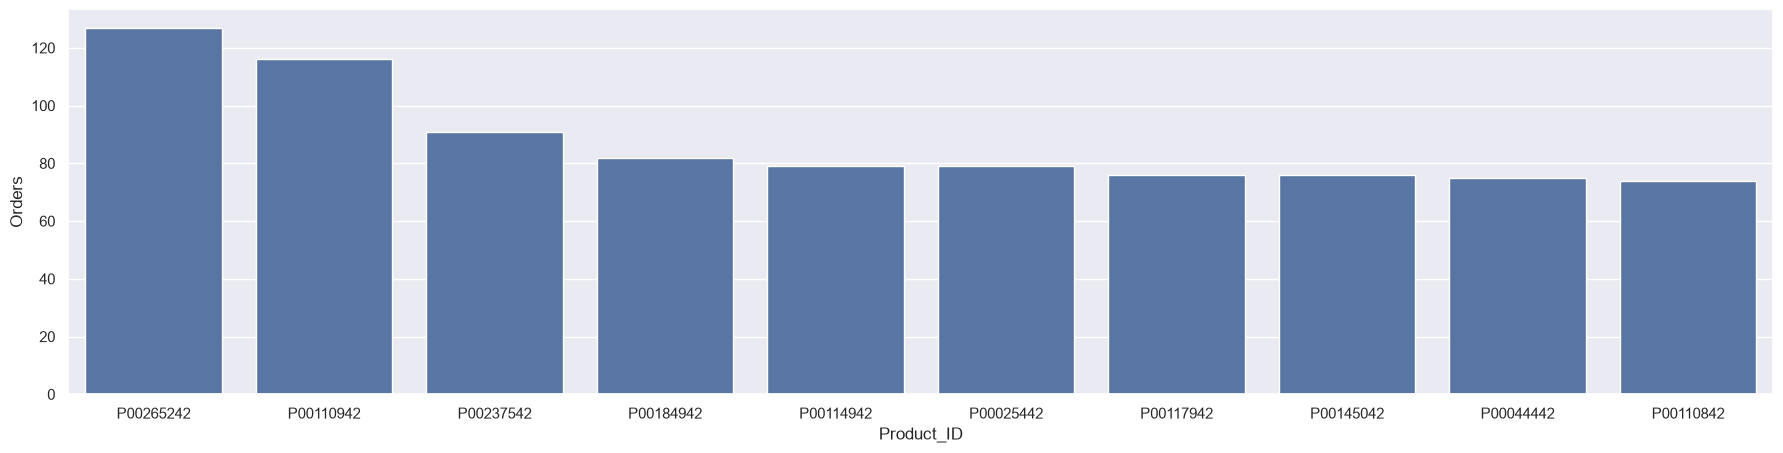

In [18]:
#visualise it
sns.barplot(x='Product_ID',y='Orders',data=sales_productID)

# Conclusion

### Married women with age group 26-35 yrs from UP, Maharastra and karnataka working in IT, Healthcare and Aviation are more likely to buy products from food , Clothing and Electronics category

##### Thank You!